In [59]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler


In [60]:
df = pd.read_csv('Country-data.csv')
dt = pd.read_csv('Country-data.csv')
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


EDA

In [61]:
df.shape

(167, 10)

In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [68]:
df.isnull().sum()

,0
country,0
child_mort,0
exports,0
health,0
imports,0
income,0
inflation,0
life_expec,0
total_fer,0
gdpp,0


In [69]:
df.duplicated().sum()

np.int64(0)

In [70]:
print(df.columns.tolist())

['country', 'child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']


In [71]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
child_mort,167.0,38.270060,40.328931,2.6000,8.250,19.30,62.10,208.00
exports,167.0,41.108976,27.412010,0.1090,23.800,35.00,51.35,200.00
health,167.0,6.815689,2.746837,1.8100,4.920,6.32,8.60,17.90
imports,167.0,46.890215,24.209589,0.0659,30.200,43.30,58.75,174.00
income,167.0,17144.688623,19278.067698,609.0000,3355.000,9960.00,22800.00,125000.00
inflation,167.0,7.781832,10.570704,-4.2100,1.810,5.39,10.75,104.00
life_expec,167.0,70.555689,8.893172,32.1000,65.300,73.10,76.80,82.80
total_fer,167.0,2.947964,1.513848,1.1500,1.795,2.41,3.88,7.49
gdpp,167.0,12964.155689,18328.704809,231.0000,1330.000,4660.00,14050.00,105000.00


In [72]:
numerical_cols = df.select_dtypes(
    include=np.number
).columns

categorical_cols = df.select_dtypes(
    exclude=np.number
).columns

print("Numerical Columns")
print(numerical_cols)

print("\nCategorical Columns")
print(categorical_cols)

Numerical Columns
Index(['child_mort', 'exports', 'health', 'imports', 'income', 'inflation',
       'life_expec', 'total_fer', 'gdpp'],
      dtype='object')

Categorical Columns
Index(['country'], dtype='object')


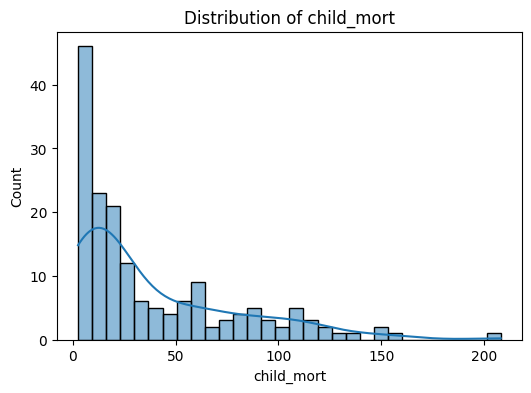

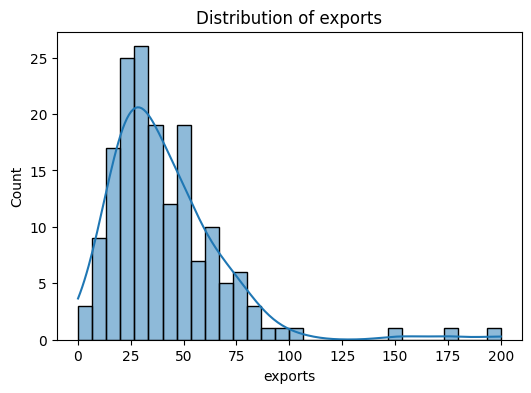

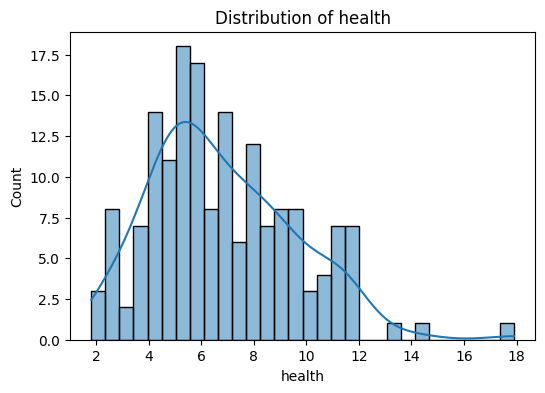

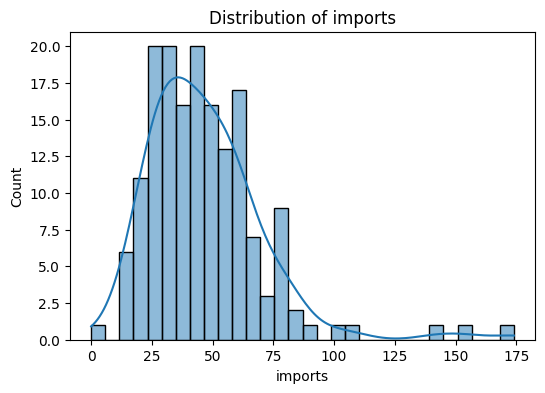

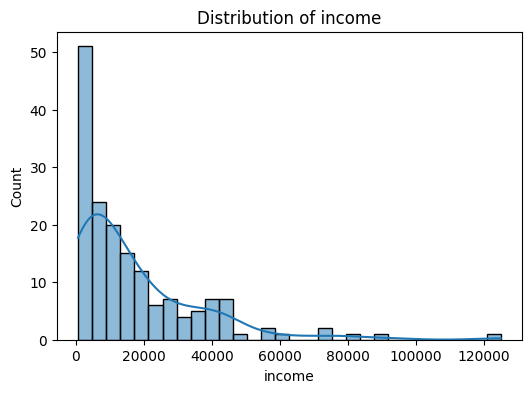

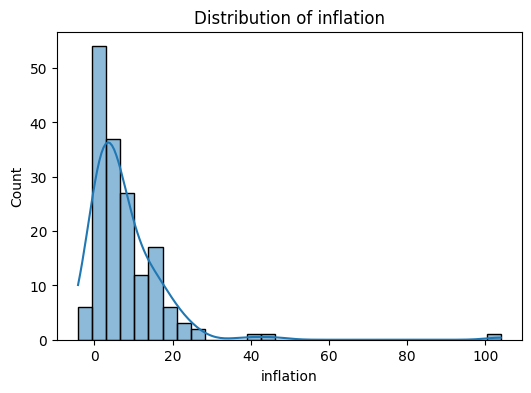

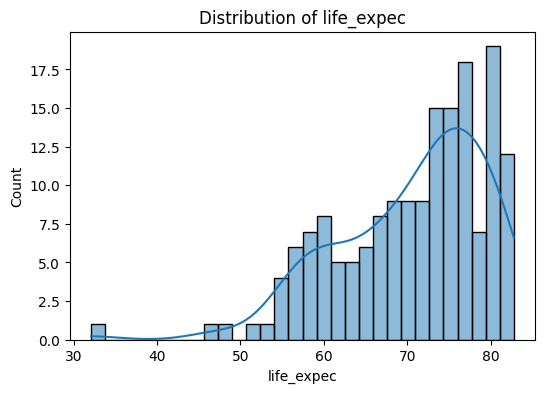

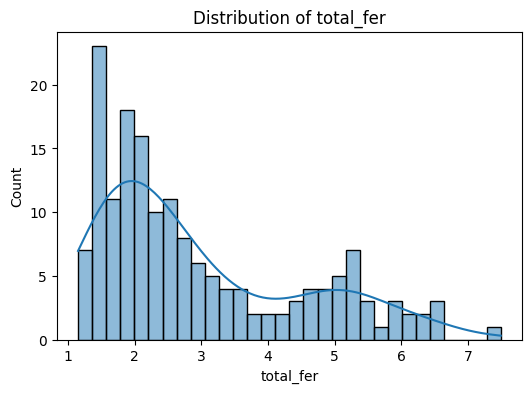

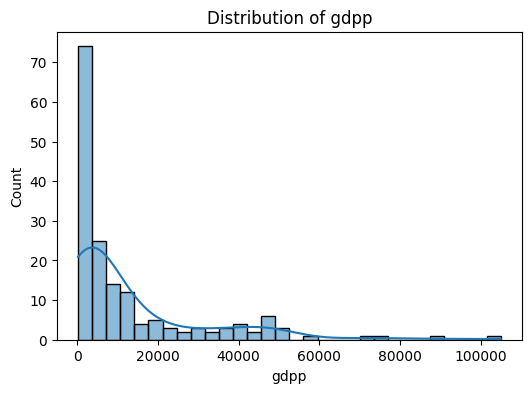

In [73]:
for col in numerical_cols:

    plt.figure(figsize=(6,4))

    sns.histplot(
        df[col],
        kde=True,
        bins=30
    )

    plt.title(f"Distribution of {col}")

    plt.show()

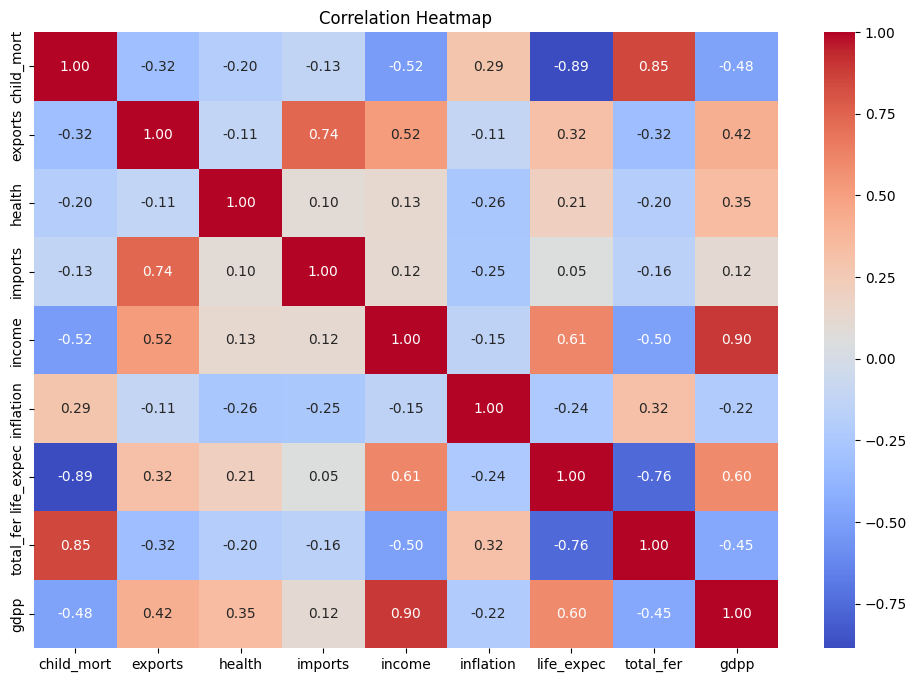

In [74]:
corr_matrix = df[numerical_cols].corr()

corr_matrix
plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")

plt.show()

In [75]:
corr_pairs = corr_matrix.unstack()

corr_pairs = corr_pairs.sort_values(
    ascending=False
)

corr_pairs.drop_duplicates()

,,0
child_mort,child_mort,1.000000
income,gdpp,0.895571
total_fer,child_mort,0.848478
exports,imports,0.737381
life_expec,income,0.611962
gdpp,life_expec,0.600089
exports,income,0.516784
gdpp,exports,0.418725
health,gdpp,0.345966
total_fer,inflation,0.316921


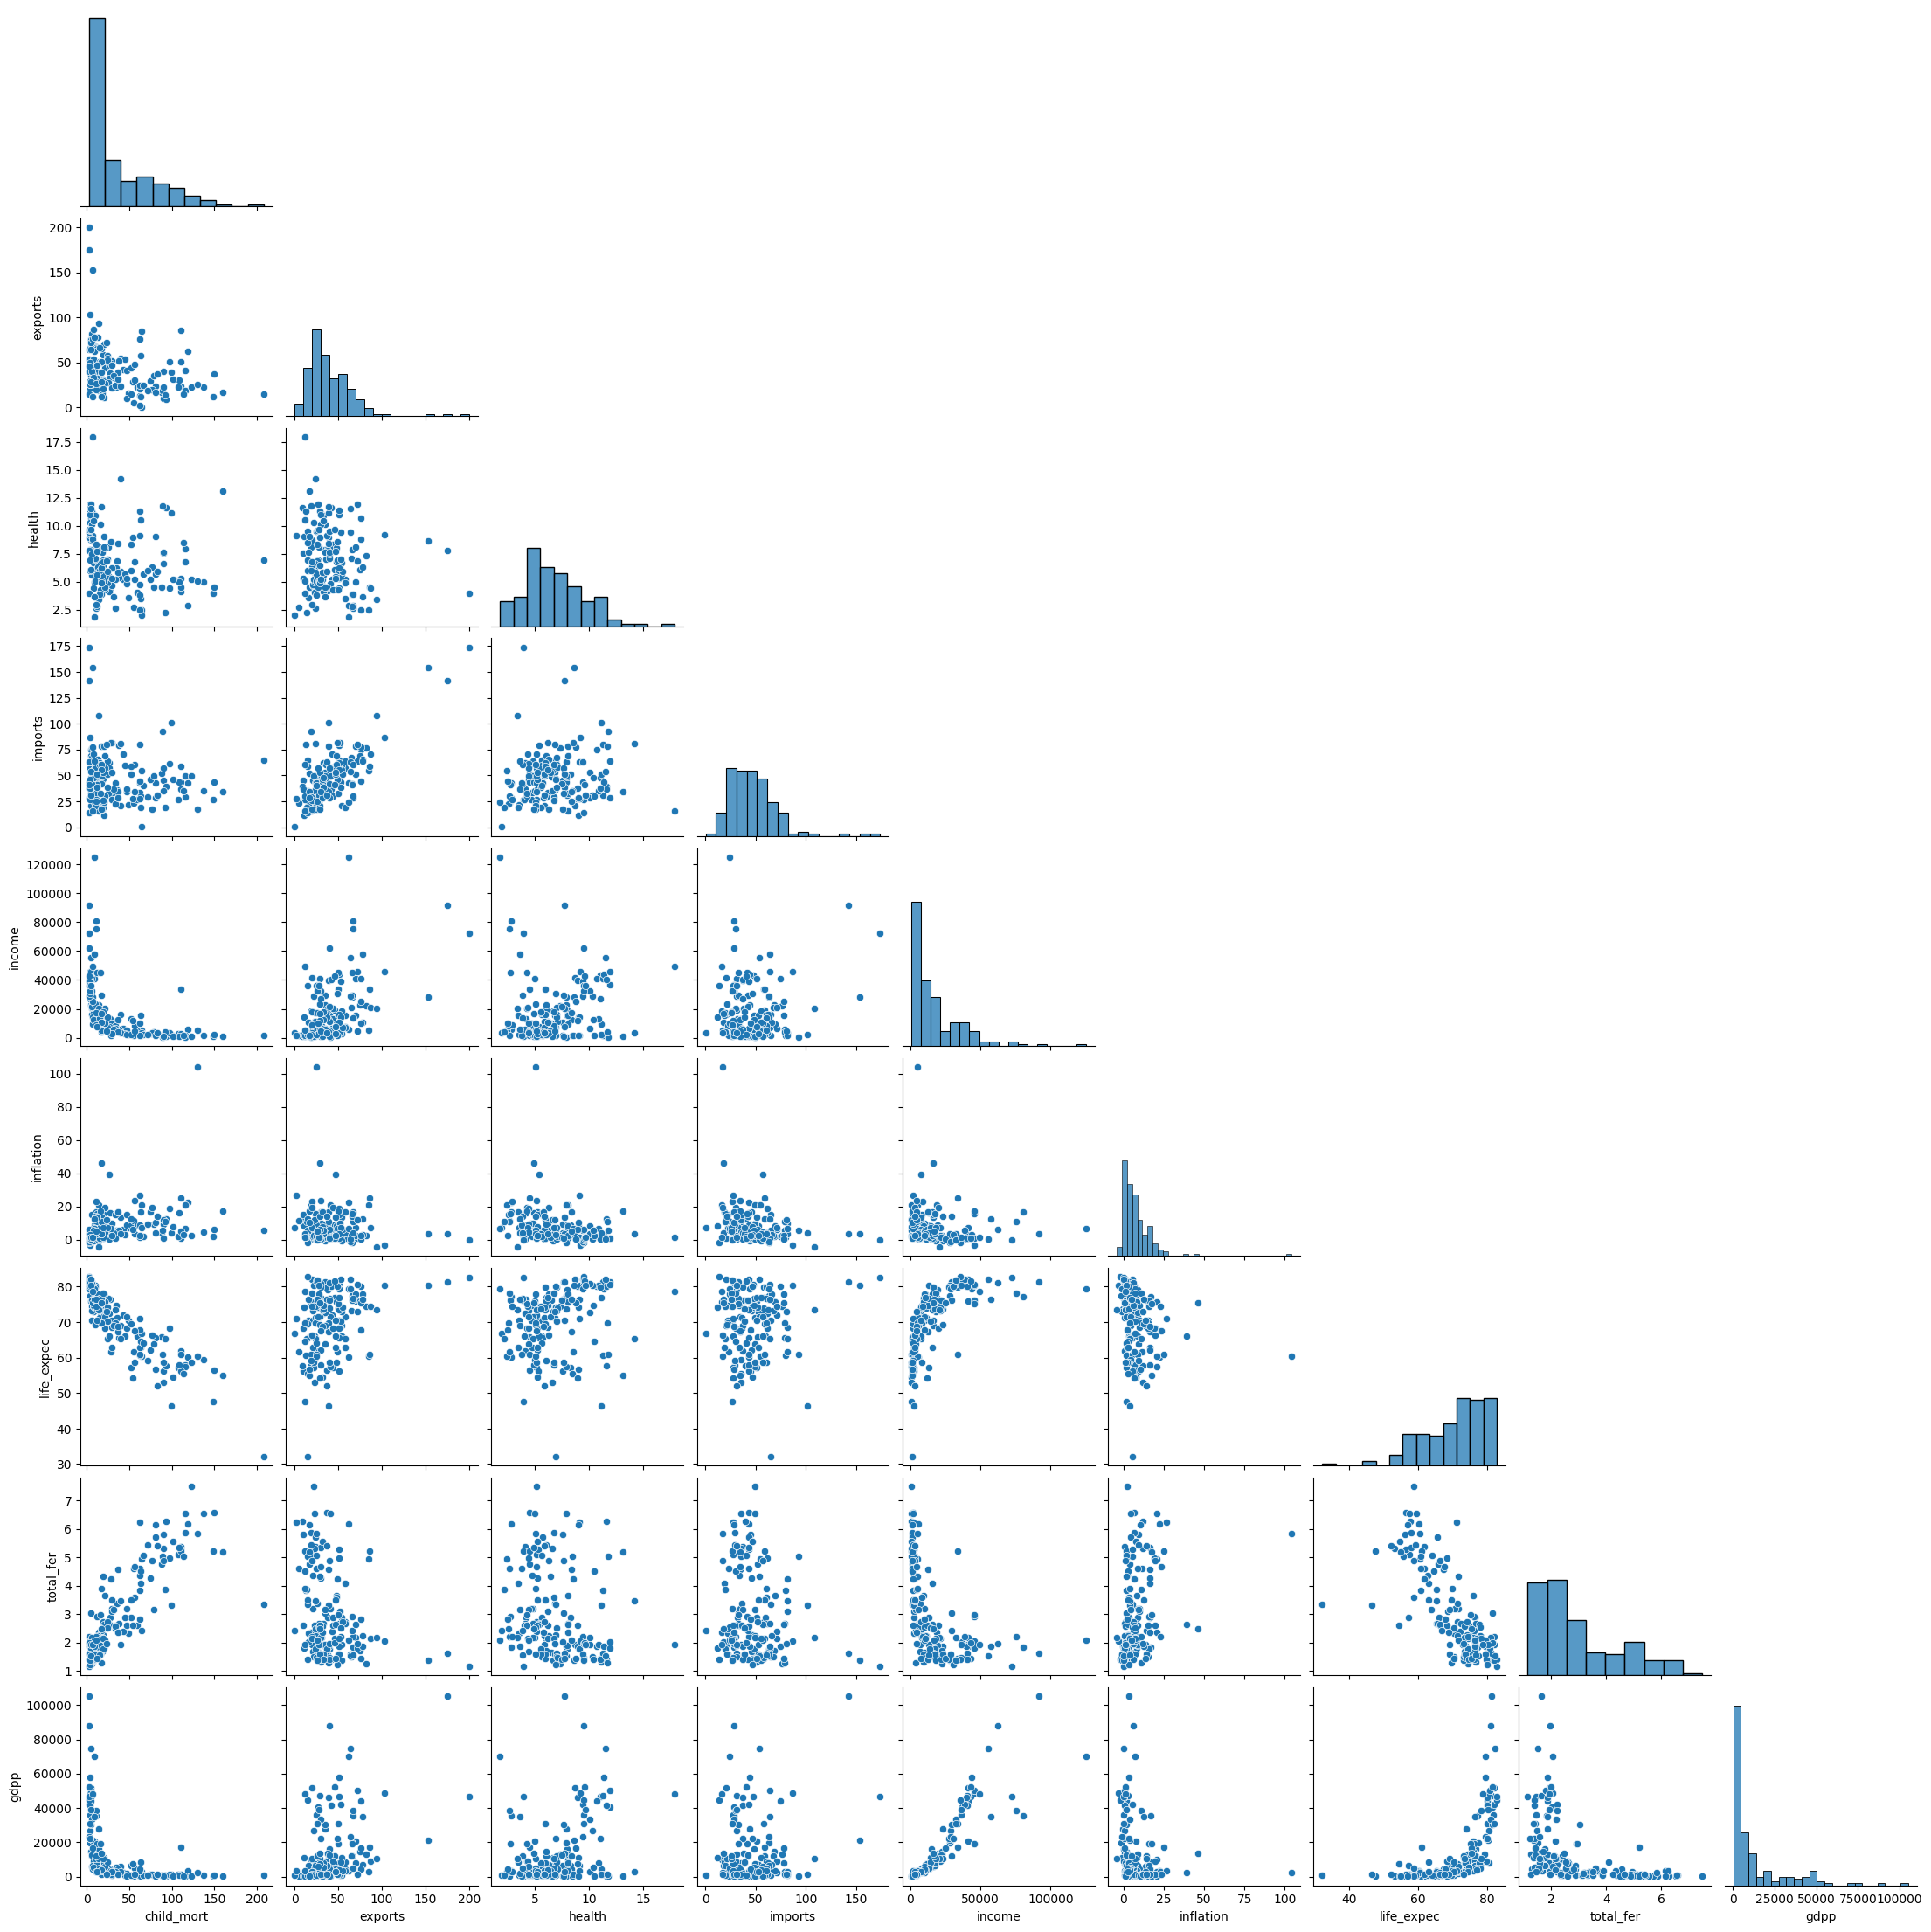

In [76]:
sns.pairplot(
    df[numerical_cols],
    corner=True
)

plt.show()

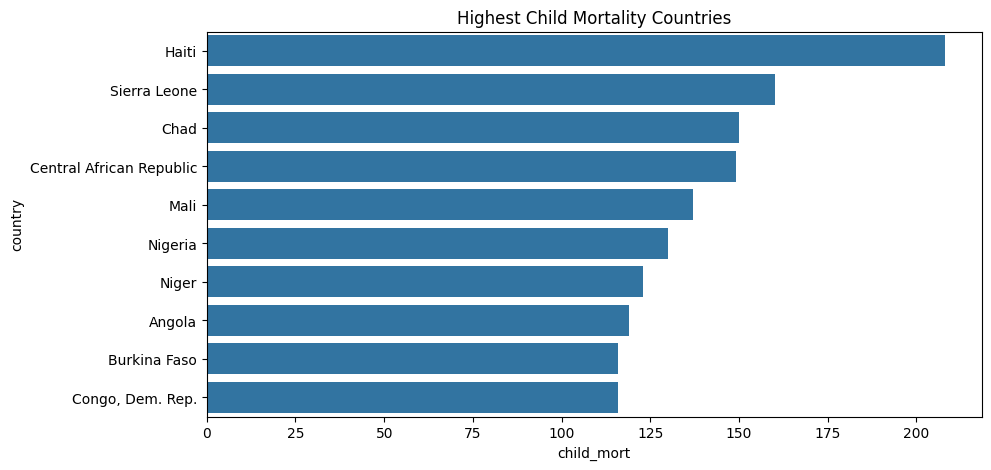

In [77]:
top_mortality = df.sort_values(
    by='child_mort',
    ascending=False
).head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    x='child_mort',
    y='country',
    data=top_mortality
)

plt.title("Highest Child Mortality Countries")

plt.show()

Country Segmentation using K-Means

In [78]:
country_names = df['country']

X = df.drop('country', axis=1)


scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

X_scaled.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,1.291532,-1.138280,0.279088,-0.082455,-0.808245,0.157336,-1.619092,1.902882,-0.679180
1,-0.538949,-0.479658,-0.097016,0.070837,-0.375369,-0.312347,0.647866,-0.859973,-0.485623
2,-0.272833,-0.099122,-0.966073,-0.641762,-0.220844,0.789274,0.670423,-0.038404,-0.465376
3,2.007808,0.775381,-1.448071,-0.165315,-0.585043,1.387054,-1.179234,2.128151,-0.516268
4,-0.695634,0.160668,-0.286894,0.497568,0.101732,-0.601749,0.704258,-0.541946,-0.041817


In [79]:
X_scaled.describe().round(2)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00
mean,-0.00,0.00,0.00,0.00,-0.00,-0.00,0.00,0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-0.89,-1.50,-1.83,-1.94,-0.86,-1.14,-4.34,-1.19,-0.70
25%,-0.75,-0.63,-0.69,-0.69,-0.72,-0.57,-0.59,-0.76,-0.64
50%,-0.47,-0.22,-0.18,-0.15,-0.37,-0.23,0.29,-0.36,-0.45
75%,0.59,0.37,0.65,0.49,0.29,0.28,0.70,0.62,0.06
max,4.22,5.81,4.05,5.27,5.61,9.13,1.38,3.01,5.04


ELBOW METHOD

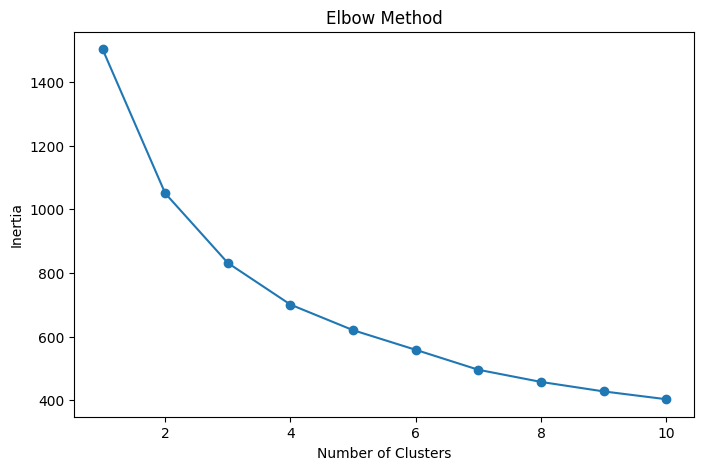

In [80]:
from sklearn.cluster import KMeans


inertia = []

for k in range(1, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    inertia,
    marker='o'
)

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

plt.title("Elbow Method")

plt.show()

In [81]:
from sklearn.metrics import silhouette_score

for k in range(2,11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    print(
        f"K={k}, Silhouette={score:.4f}"
    )

K=2, Silhouette=0.2874
K=3, Silhouette=0.2833
K=4, Silhouette=0.2960
K=5, Silhouette=0.2993
K=6, Silhouette=0.2287
K=7, Silhouette=0.2477
K=8, Silhouette=0.2388
K=9, Silhouette=0.2073
K=10, Silhouette=0.2022


In [82]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

In [83]:
df['Cluster'].value_counts()

,count
Cluster,
2,85
1,47
0,32
3,3


In [84]:
cluster_profile = df.groupby('Cluster').mean(
    numeric_only=True
)

cluster_profile

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
Cluster,,,,,,,,,
0,5.181250,46.118750,9.088437,40.584375,44021.875000,2.513844,80.081250,1.788437,42118.750000
1,92.961702,29.151277,6.388511,42.323404,3942.404255,12.019681,59.187234,5.008085,1922.382979
2,21.690588,41.073988,6.197059,47.914893,12671.411765,7.609341,72.871765,2.300706,6519.552941
3,4.133333,176.000000,6.793333,156.666667,64033.333333,2.468000,81.433333,1.380000,57566.666667


In [85]:
for i in range(4):
    print(f"\nCluster {i}")
    print(df[df['Cluster']==i]['country'].tolist())


Cluster 0
['Australia', 'Austria', 'Bahamas', 'Belgium', 'Brunei', 'Canada', 'Cyprus', 'Czech Republic', 'Denmark', 'Finland', 'France', 'Germany', 'Greece', 'Iceland', 'Ireland', 'Israel', 'Italy', 'Japan', 'Kuwait', 'Netherlands', 'New Zealand', 'Norway', 'Portugal', 'Qatar', 'Slovenia', 'South Korea', 'Spain', 'Sweden', 'Switzerland', 'United Arab Emirates', 'United Kingdom', 'United States']

Cluster 1
['Afghanistan', 'Angola', 'Benin', 'Botswana', 'Burkina Faso', 'Burundi', 'Cameroon', 'Central African Republic', 'Chad', 'Comoros', 'Congo, Dem. Rep.', 'Congo, Rep.', "Cote d'Ivoire", 'Equatorial Guinea', 'Eritrea', 'Gabon', 'Gambia', 'Ghana', 'Guinea', 'Guinea-Bissau', 'Haiti', 'Iraq', 'Kenya', 'Kiribati', 'Lao', 'Lesotho', 'Liberia', 'Madagascar', 'Malawi', 'Mali', 'Mauritania', 'Mozambique', 'Namibia', 'Niger', 'Nigeria', 'Pakistan', 'Rwanda', 'Senegal', 'Sierra Leone', 'South Africa', 'Sudan', 'Tanzania', 'Timor-Leste', 'Togo', 'Uganda', 'Yemen', 'Zambia']

Cluster 2
['Albania'

PCA

In [86]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_data = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    pca_data,
    columns=['PC1','PC2']
)

pca_df['Cluster'] = clusters

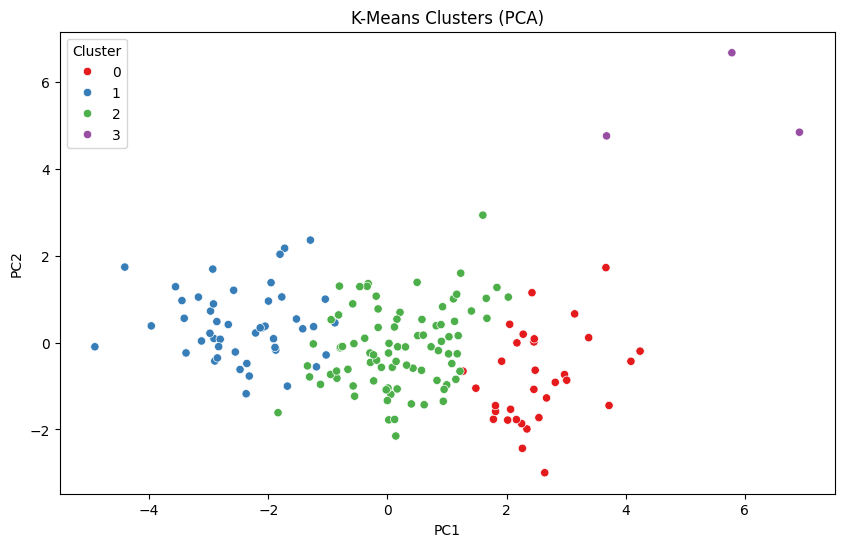

In [87]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette='Set1'
)

plt.title('K-Means Clusters (PCA)')
plt.show()

DBSCAN

In [88]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=1.5,
    min_samples=5
)

db_labels = dbscan.fit_predict(X_scaled)

df['DBSCAN_Cluster'] = db_labels

In [89]:
df['DBSCAN_Cluster'].value_counts()

,count
DBSCAN_Cluster,
0,137
-1,30


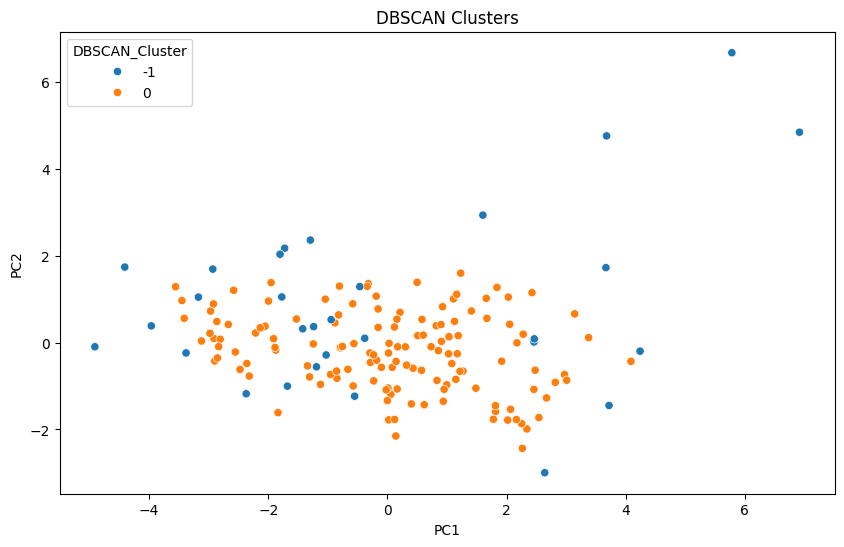

In [90]:
pca_df['DBSCAN_Cluster'] = db_labels

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='DBSCAN_Cluster',
    palette='tab10'
)

plt.title("DBSCAN Clusters")
plt.show()

In [91]:
outliers = df[df["DBSCAN_Cluster"] == -1]

outliers["country"].tolist()

['Angola',
 'Brunei',
 'Central African Republic',
 'Congo, Dem. Rep.',
 'Congo, Rep.',
 'Equatorial Guinea',
 'Gabon',
 'Haiti',
 'Iraq',
 'Ireland',
 'Kiribati',
 'Kuwait',
 'Lesotho',
 'Liberia',
 'Luxembourg',
 'Malta',
 'Micronesia, Fed. Sts.',
 'Mongolia',
 'Nigeria',
 'Norway',
 'Qatar',
 'Rwanda',
 'Seychelles',
 'Sierra Leone',
 'Singapore',
 'South Africa',
 'Timor-Leste',
 'Turkmenistan',
 'United States',
 'Venezuela']

In [92]:
cluster_mapping = {
    0: "Developed",
    1: "Underdeveloped",
    2: "Developing",
    3: "Elite"
}

df["Development_Class"] = (
    df["Cluster"]
    .map(cluster_mapping)
)

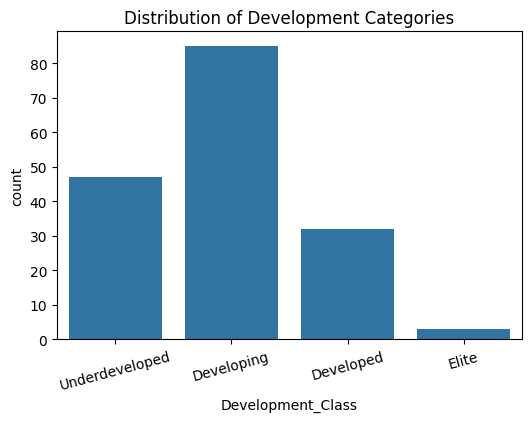

In [93]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Development_Class',
    data=df
)

plt.title("Distribution of Development Categories")
plt.xticks(rotation=15)
plt.show()

In [94]:
X = df.drop(
    [
        "country",
        "Cluster",
        "Development_Class",
        "DBSCAN_Cluster"
    ],
    axis=1
)

In [95]:
score = silhouette_score(X_scaled, df["Cluster"])

print("Silhouette Score:", score)

Silhouette Score: 0.29595170577528157


In [96]:
df[
["country",
 "Cluster",
 "Development_Class"]
].head()

,country,Cluster,Development_Class
0,Afghanistan,1,Underdeveloped
1,Albania,2,Developing
2,Algeria,2,Developing
3,Angola,1,Underdeveloped
4,Antigua and Barbuda,2,Developing


In [97]:
df["Target"] = df["Cluster"]
y = df["Target"]

In [98]:
X = df.drop(
    [
        "country",
        "Cluster",
        "Development_Class",
        "Target"
    ],
    axis=1
)

y = df["Target"]

TRAIN TEST SPLIT

In [99]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = (
    train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )
)

RANDOM FOREST

In [100]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [101]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print(
    "Accuracy:",
    accuracy_score(
        y_test,
        rf_pred
    )
)

print(
    classification_report(
        y_test,
        rf_pred
    )
)

Accuracy: 0.9411764705882353
              precision    recall  f1-score   support

           0       1.00      0.83      0.91         6
           1       1.00      1.00      1.00        10
           2       0.89      1.00      0.94        17
           3       0.00      0.00      0.00         1

    accuracy                           0.94        34
   macro avg       0.72      0.71      0.71        34
weighted avg       0.92      0.94      0.93        34



In [102]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, None]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

print("Best Parameters:")
print(grid_rf.best_params_)

print("\nBest Cross Validation Score:")
print(grid_rf.best_score_)

Best Parameters:
{'max_depth': 5, 'n_estimators': 100}

Best Cross Validation Score:
0.9404558404558404


In [103]:
tuned_pred = grid_rf.predict(X_test)

print(
    "Tuned RF Accuracy:",
    accuracy_score(y_test, tuned_pred)
)

Tuned RF Accuracy: 0.9411764705882353


In [104]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = (
    importance
    .sort_values(
        "Importance",
        ascending=False
    )
)

print(importance)

          Feature  Importance
0      child_mort    0.239648
8            gdpp    0.217617
6      life_expec    0.176016
7       total_fer    0.163756
4          income    0.101480
2          health    0.026843
1         exports    0.026411
3         imports    0.025115
5       inflation    0.015423
9  DBSCAN_Cluster    0.007691


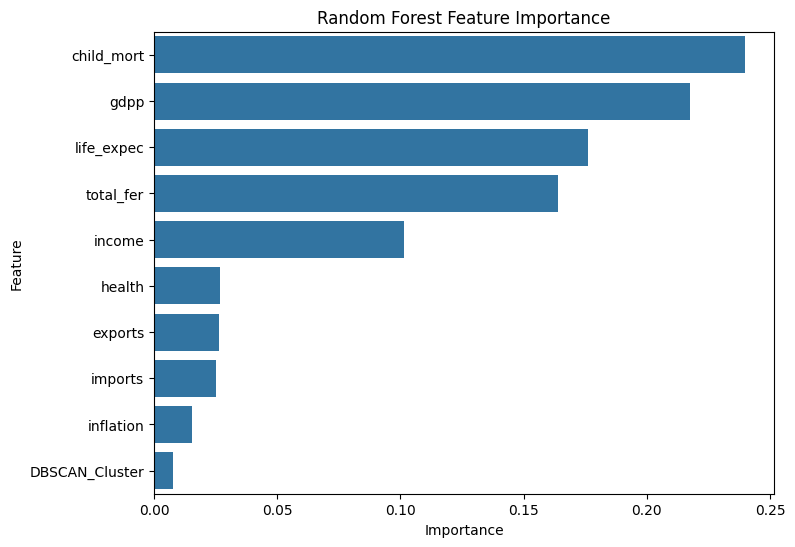

In [105]:
plt.figure(figsize=(8,6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title(
    "Random Forest Feature Importance"
)

plt.show()

XGBOOST


In [106]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    random_state=42
)

xgb.fit(
    X_train,
    y_train
)

xgb_pred = xgb.predict(
    X_test
)

In [107]:
print(
    accuracy_score(
        y_test,
        xgb_pred
    )
)

print(
    classification_report(
        y_test,
        xgb_pred
    )
)

0.9411764705882353
              precision    recall  f1-score   support

           0       1.00      0.83      0.91         6
           1       1.00      1.00      1.00        10
           2       0.89      1.00      0.94        17
           3       0.00      0.00      0.00         1

    accuracy                           0.94        34
   macro avg       0.72      0.71      0.71        34
weighted avg       0.92      0.94      0.93        34



In [108]:
xgb_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2]
}

grid_xgb = GridSearchCV(
    XGBClassifier(
        random_state=42,
        eval_metric='mlogloss'
    ),
    xgb_param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid_xgb.fit(X_train, y_train)

print("Best Parameters:")
print(grid_xgb.best_params_)

print("\nBest CV Score:")
print(grid_xgb.best_score_)

Best Parameters:
{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}

Best CV Score:
0.9247474747474748


In [109]:
from sklearn.metrics import accuracy_score

xgb_tuned_pred = grid_xgb.predict(X_test)

print(
    "Tuned XGBoost Accuracy:",
    accuracy_score(y_test, xgb_tuned_pred)
)

Tuned XGBoost Accuracy: 0.9411764705882353


In [110]:
xgb_tuned_pred = grid_xgb.predict(X_test)

xgb_tuned_acc = accuracy_score(y_test, xgb_tuned_pred)

print("Tuned XGBoost Accuracy:", xgb_tuned_acc)

Tuned XGBoost Accuracy: 0.9411764705882353


In [111]:
df[df["Cluster"] == 3]["country"]
print("Elite Economies:")
print(df[df["Cluster"] == 3]["country"].tolist())

Elite Economies:
['Luxembourg', 'Malta', 'Singapore']


In [112]:
results = pd.DataFrame({
    "Model":["Random Forest","XGBoost"],
    "Accuracy":[rf_acc,xgb_acc]
})

print(results)

           Model  Accuracy
0  Random Forest  0.941176
1        XGBoost  0.941176


In [113]:
comparison = pd.DataFrame({
    "Technique": [
        "K-Means",
        "DBSCAN",
        "Random Forest",
        "XGBoost"
    ],
    "Purpose": [
        "Country Segmentation",
        "Outlier Detection",
        "Classification",
        "Classification"
    ]
})

comparison

,Technique,Purpose
0,K-Means,Country Segmentation
1,DBSCAN,Outlier Detection
2,Random Forest,Classification
3,XGBoost,Classification


# Conclusion

This project successfully developed an end-to-end Country Intelligence System using clustering and classification techniques.

K-Means clustering segmented countries into four meaningful development groups: Developed, Developing, Underdeveloped, and Elite Economies. PCA visualization confirmed clear separation among these clusters.

Random Forest and XGBoost achieved an accuracy of 94.12% in predicting development categories. Feature importance analysis revealed that child mortality, GDP per capita, life expectancy, fertility rate, and income are the most influential indicators of development status.

DBSCAN identified 30 outlier countries with unique socio-economic characteristics.

Overall, the project demonstrates how clustering, ensemble learning, and predictive analytics can be combined to generate actionable socio-economic insights.